# Santiago Marin Yepes

# Código de comparación de la solución analítica y numérica, con la tolerancia como parámetro del número de iteraciones.

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [ ]:
def Solucion_numerica(V_ini,tol,x,y):
  '''Int the V initial configutaration.\n Niter is the number of the itertions of the algorithm.
  x(y) the array in x(y) variable.
  Return X,Y,Z evolve Niter times using finite differences for the Laplace case.'''
  Nx, Ny = V_ini.shape
  V = V_ini.copy()
  m=0
  k=True
  start = time.perf_counter()
  while k: # iterations over algorithm. Niter times
    V2=V.copy()
    for i in range(1, Nx-1):
      for j in range(1,Ny-1):
        V[i,j] = 0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
    if np.max(np.abs(V-V2))<tol:# Se verifica que la solución cumpla con el valor de tolerancia deseado
      k=False
    m=m+1
  end = time.perf_counter()
  X, Y = np.meshgrid(x,y)
  t=end - start
  return X,Y,V,t,m

In [ ]:
def un1(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 #Voltage
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)
def Solucion_analitica1(un,x,y,L,Tol):
 coordx = np.linspace(0,L,100)
 coordy = coordx
 x , y = np.meshgrid(coordx, coordy, indexing= 'ij')
 z = 0
 k=True
 m=0
 n=0
 start1 = time.perf_counter()
 while k: #Loop para ir sumando terminos a la solucion
   n = m*2+1 #Termino n-esimo sumado
   m += 1
   z1 = np.linalg.norm(z)
   z += un(x,y,n,L)
   z2 = np.linalg.norm(z)
   if np.abs(z2-z1)/z2 < Tol:# Se verifica que la solución cumpla con el valor de tolerancia deseado
     k=False
 end1 = time.perf_counter()
 t1=end1 - start1
 return x,y,z,t1,m

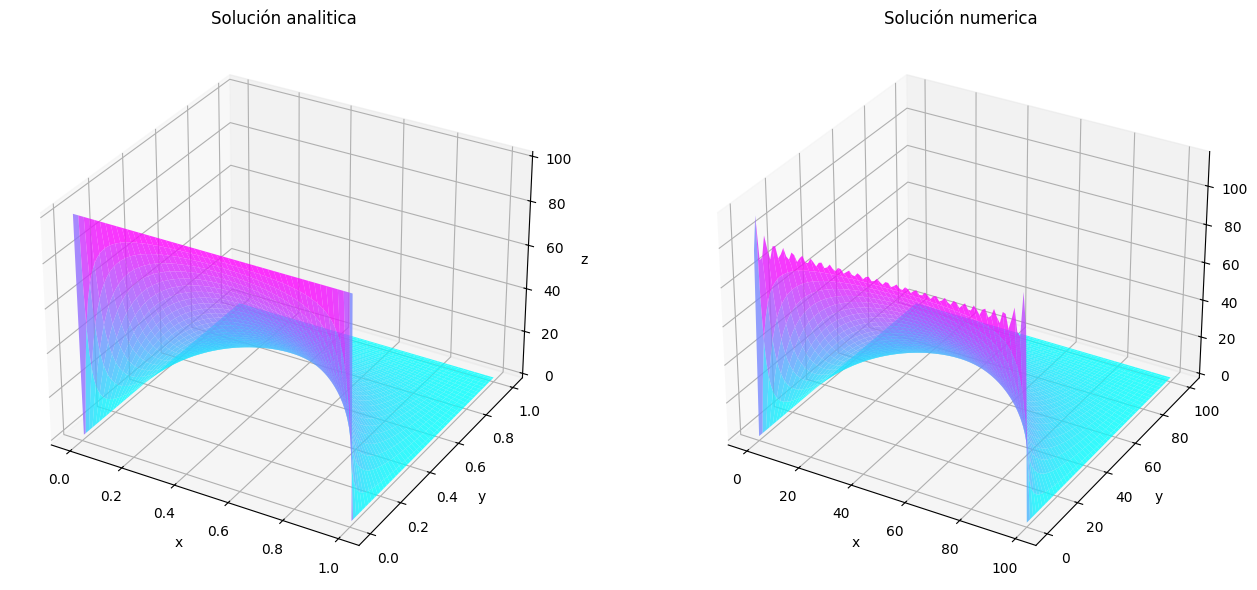

Execution time(numerica): 95.90841818700028, Execution time(analitica): 0.013917693000166764
numero de iteraciones (29, 8232)


In [ ]:
# @title
import matplotlib.pyplot as plt
Nmax = 100
V_ini = np.zeros((Nmax, Nmax), float)
V_ini[0,:] = 100.0
L=100
x=np.linspace(0,1,Nmax)
y=np.linspace(0,1,Nmax)
tol=10**-5


x1,y1,z1,t1,m1 = Solucion_numerica(V_ini,tol,x,y)
x2,y2,z2,t2,m2 = Solucion_analitica1(un1,x,y,L,tol)


fig = plt.figure(figsize=(14, 6))

# First plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1, y1, z1, cmap='cool', alpha=0.8)
ax1.set_title('Solución analitica')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# Second plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(x2, y2, z2, cmap='cool', alpha=0.8)
ax2.set_title('Solución numerica')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

print(f'Execution time(numerica): {t1}, Execution time(analitica): {t2}')
print(f'numero de iteraciones {m2,m1}')

En el anterior grafico podemos ver la solucion analitica y la solucion numerica. Se puede notar que la solucion analitica ondula en los valores de la frontera, mientras que la solucion numerica es constante como era esperado. Ademas que la solucion analitica tiene problemas en las esquina "the corners Gibbs overshoot" mientras la numerica no tiene este fenomeno. cabe destacar que el tiempo de computacion para una tolerancia de $10^{-3}$ es mayor para la solucion numerica que para la analitica. Se necesitaron 50 terminos de la funcion analitica pera conseguir la tolerancia.

la solución analitica debe tomar alrededor de 11 terminos. la numerica 106... verificar. Nota 4.5

#Este código muestra una solución numérica de la ecuación de Laplace para $x(∞) =0$

In [ ]:
def f(x, u0, L):
    return u0 * np.sin(2*np.pi*x/L)
def un2(x,y,U0,L):
  return U0*np.sin((2*np.pi*x)/L)*np.exp(-(2*np.pi*y)/(L))
def Solucion_analitica2(un,x,y,L):
 Nx=len(x)
 Ny=len(y)
 coordx = np.linspace(0,np.max(x),Nx)
 coordy = np.linspace(0,np.max(y),Ny)
 x , y = np.meshgrid(coordx, coordy, indexing= 'ij')
 z = un(x,y,100,L)
 return x,y,z

In [ ]:
N = 100
L=100
Ly=250
x = np.linspace(0, L, N)
y = np.linspace(0, Ly, N)

U_ini = np.zeros((len(x), len(y)))
U_ini[:,0] = 0
U_ini[0,:] = 100*np.sin(2*np.pi*x/L)
U_ini[-1,:] = 0
U_ini[:,-1] = 0

Dado que la solución analítica presenta un decaimiento exponencial, y que para $L_y = 250$ los valores son del orden de $10^{-6}$, se puede considerar que dicho valor aproxima adecuadamente el infinito.

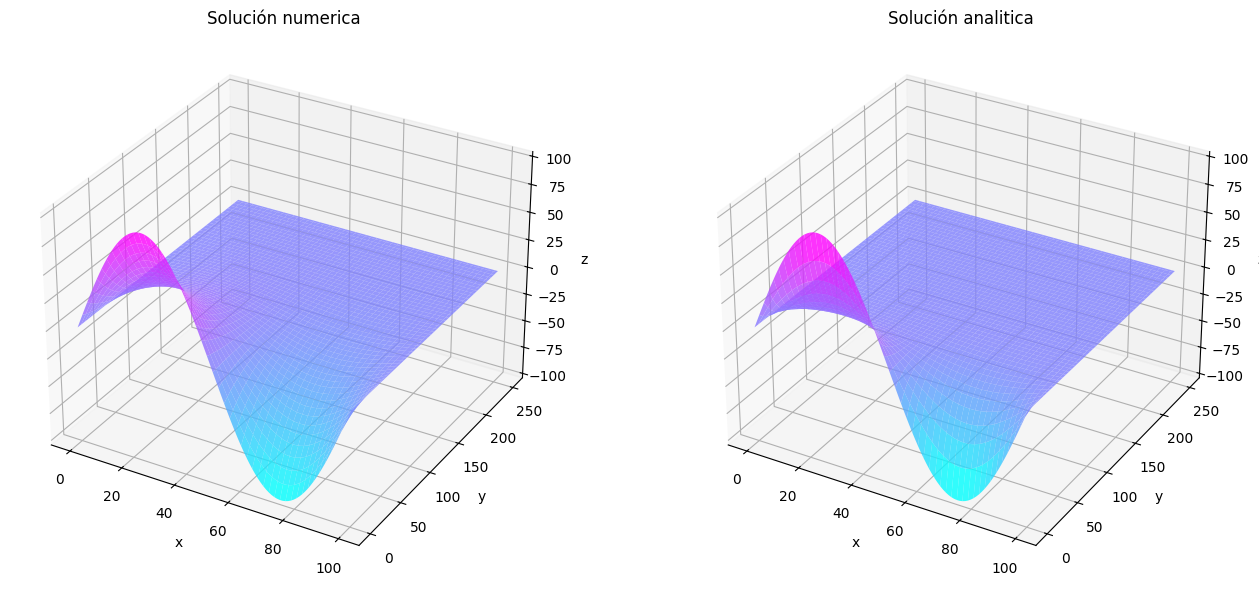

In [ ]:
# @title
x3,y3,z3,t3,m3=Solucion_numerica(U_ini,tol,x,y)
x4,y4,z4=Solucion_analitica2(un2,x,y,L)


fig = plt.figure(figsize=(14, 6))


ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x3, y3, z3, cmap='cool', alpha=0.8)
ax1.set_title('Solución numerica')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# Second plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(x4, y4, z4, cmap='cool', alpha=0.8)
ax2.set_title('Solución analitica')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.tight_layout()
plt.show()

Dado que la solución analítica se obtiene evaluando un único modo $n$, esta representa la forma exacta de la solución. Por ello, no se presentan inconsistencias en las esquinas del dominio y la solución numérica concuerda adecuadamente con la solución analítica.